<a href="https://colab.research.google.com/github/UST-MSAI-Neural-Prognosis/AI-Prognosis-System/blob/david_branch/SEIS_764_Final_Project_Master_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import os, glob, sqlite3
import pandas as pd
from IPython.display import display
from google.colab import drive

drive.mount('/content/drive')
# --- 1) Config: Everyone uses this same config ---

# This is the name of the folder you shared and they created a shortcut to
SHARED_FOLDER_NAME = "Project_Data"
DATASET_NAME = "dataset.csv"
DB_NAME = "dataset.db"

# Build the full, shared paths
# This path will work for EVERYONE, *if* they followed the instructions
# to add the shortcut to their "My Drive"
BASE_PATH = os.path.join("/content/drive/MyDrive", SHARED_FOLDER_NAME)
CSV_PATH = os.path.join(BASE_PATH, DATASET_NAME)
DB_PATH = os.path.join(BASE_PATH, DB_NAME)

TABLE_NAME = "dataset"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# --- 2) Utility: find the CSV in your Drive (MyDrive); searches recursively if needed ---
def find_csv_in_mydrive(filename=DATASET_NAME):
    # Common direct location
    direct = f"/content/drive/MyDrive/{filename}"
    if os.path.exists(direct):
        return direct
    # Recursive search (can take a bit if you have a lot of files)
    matches = glob.glob(f"/content/drive/MyDrive/**/{filename}", recursive=True)
    if matches:
        return matches[0]
    raise FileNotFoundError(
        f"Could not find {filename} under /content/drive/MyDrive. "
        f"Try moving it there or update DATASET_NAME/paths."
    )


In [ ]:
# --- 3) Load CSV into SQLite helper ---
def load_csv_to_sqlite(csv_path, db_path=DB_PATH, table_name=TABLE_NAME, chunksize=100_000):
    """
    Loads a CSV into SQLite using pandas.to_sql.
    - Uses chunking for large files.
    - Replaces the table on the first chunk, then appends.
    """
    con = sqlite3.connect(db_path)
    try:
        first = True
        for chunk in pd.read_csv(csv_path, chunksize=chunksize):
            chunk.to_sql(table_name, con, if_exists="replace" if first else "append", index=False)
            first = False
        con.commit()
    finally:
        con.close()

In [ ]:
def query_db(sql, params=None, db_path=DB_PATH):
    """
    Run a SELECT (or PRAGMA) and return a pandas DataFrame.
    """
    con = sqlite3.connect(db_path)
    try:
        df = pd.read_sql_query(sql, con, params=params)
        return df
    finally:
        con.close()

In [ ]:
csv_path = find_csv_in_mydrive(DATASET_NAME)
print(f"Using CSV: {csv_path}")

# Create/overwrite DB & load data
load_csv_to_sqlite(csv_path, db_path=DB_PATH, table_name=TABLE_NAME)
print(f"Loaded data into {DB_PATH} (table: {TABLE_NAME})")

# Show schema (column list) and a sample query
schema_df = query_db(f"PRAGMA table_info({TABLE_NAME});")
print("\nTable schema:")
display(schema_df)

# Below code puts the ALL data from the csv into a pandas dataframe
df = query_db(f"SELECT * FROM {TABLE_NAME};")
print("\nSample rows:")
display(df.head(10))

Using CSV: /content/drive/MyDrive/dataset.csv
Loaded data into /content/drive/MyDrive/Project_Data/dataset.db (table: dataset)

Table schema:


,cid,name,type,notnull,dflt_value,pk
0,0,feeling.nervous,TEXT,0,None,0
1,1,panic,TEXT,0,None,0
2,2,breathing.rapidly,TEXT,0,None,0
3,3,sweating,TEXT,0,None,0
4,4,trouble.in.concentration,TEXT,0,None,0
5,5,having.trouble.in.sleeping,TEXT,0,None,0
6,6,having.trouble.with.work,TEXT,0,None,0
7,7,hopelessness,TEXT,0,None,0
8,8,anger,TEXT,0,None,0
9,9,over.react,TEXT,0,None,0



Sample rows:


,feeling.nervous,panic,breathing.rapidly,sweating,trouble.in.concentration,having.trouble.in.sleeping,having.trouble.with.work,hopelessness,anger,over.react,...,weight.gain,material.possessions,introvert,popping.up.stressful.memory,having.nightmares,avoids.people.or.activities,feeling.negative,trouble.concentrating,blamming.yourself,Disorder
0,no,no,no,no,no,no,no,no,no,no,...,yes,yes,yes,no,no,no,no,no,no,Loneliness
1,no,no,no,no,no,no,yes,yes,yes,yes,...,no,no,no,no,no,no,no,no,no,Depression
2,no,no,no,no,no,no,no,no,no,no,...,no,no,no,yes,yes,yes,yes,yes,yes,Stress
3,no,no,no,no,no,no,no,no,no,no,...,yes,yes,yes,no,no,no,no,no,no,Loneliness
4,no,no,no,no,no,no,no,no,no,no,...,no,no,no,yes,yes,yes,yes,yes,yes,Stress
5,yes,yes,yes,yes,yes,yes,no,no,no,no,...,no,no,no,no,no,no,no,no,no,Anxiety
6,no,no,no,no,no,no,no,no,no,no,...,yes,yes,yes,no,no,no,no,no,no,Loneliness
7,yes,yes,yes,yes,yes,yes,no,no,no,no,...,no,no,no,no,no,no,no,no,no,Anxiety
8,yes,yes,yes,yes,yes,yes,no,no,no,no,...,no,no,no,no,no,no,no,no,no,Anxiety
9,no,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,no,Normal


In [ ]:
sample_df = query_db(f"SELECT disorder, count(disorder) as num_of_records_with_disorder FROM {TABLE_NAME} group by disorder;")
print("\nSample rows:")
display(sample_df)


Sample rows:


,Disorder,num_of_records_with_disorder
0,Anxiety,8192
1,Depression,15018
2,Loneliness,30037
3,Normal,9011
4,Stress,27033


In [ ]:
# --- 2.2 Pre-training: Data & preprocessing ---

import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print("Raw dataframe shape:", df.shape)

# 1) Separate features and target
TARGET_COL = "Disorder"

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

print("Feature columns:", list(X.columns))
print("Target column:", TARGET_COL)
print("\nTarget class counts:")
print(y.value_counts())

# 2) Encode yes/no symptom columns as 0/1
yes_no_map = {"yes": 1, "no": 0}

for col in X.columns:
    X[col] = (
        X[col]
        .astype(str)       # safety
        .str.strip()
        .str.lower()
        .map(yes_no_map)
    )

# Sanity check for any unexpected values
problem_cols = [c for c in X.columns if X[c].isna().any()]
if problem_cols:
    print("\n[WARNING] Some columns had values other than yes/no:", problem_cols)
else:
    print("\nAll feature columns successfully encoded as 0/1.")

X = X.astype("float32")

# 3) Encode target labels as integers (0..num_classes-1)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nLabel encoder classes (index -> label):")
for idx, cls in enumerate(label_encoder.classes_):
    print(f"{idx}: {cls}")

# 4) Train / validation / test split (70% / 15% / 15%), stratified by class
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,           # 30% goes to temp (val+test)
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,           # split temp into 15% val, 15% test
    random_state=42,
    stratify=y_temp
)

print("\nSplit shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

# 5) Convert to NumPy arrays (good for Keras / PyTorch later)
X_train = X_train.values.astype("float32")
X_val   = X_val.values.astype("float32")
X_test  = X_test.values.astype("float32")

y_train = np.asarray(y_train, dtype="int64")
y_val   = np.asarray(y_val, dtype="int64")
y_test  = np.asarray(y_test, dtype="int64")

# 6) Optional: compute class weights to handle class imbalance in training
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {int(cls): float(w) for cls, w in zip(np.unique(y_train), class_weights_arr)}

print("\nClass weights (for model.fit(class_weight=...)):")
for cls_idx, w in class_weights.items():
    print(f"  {cls_idx} ({label_encoder.classes_[cls_idx]}): {w:.4f}")

# 7) Handy variables for the model definition step
num_features = X_train.shape[1]
num_classes  = len(label_encoder.classes_)

print("\nnum_features:", num_features)
print("num_classes:", num_classes)


Raw dataframe shape: (89291, 25)
Feature columns: ['feeling.nervous', 'panic', 'breathing.rapidly', 'sweating', 'trouble.in.concentration', 'having.trouble.in.sleeping', 'having.trouble.with.work', 'hopelessness', 'anger', 'over.react', 'change.in.eating', 'suicidal.thought', 'feeling.tired', 'close.friend', 'social.media.addiction', 'weight.gain', 'material.possessions', 'introvert', 'popping.up.stressful.memory', 'having.nightmares', 'avoids.people.or.activities', 'feeling.negative', 'trouble.concentrating', 'blamming.yourself']
Target column: Disorder

Target class counts:
Disorder
Loneliness    30037
Stress        27033
Depression    15018
Normal         9011
Anxiety        8192
Name: count, dtype: int64

All feature columns successfully encoded as 0/1.

Label encoder classes (index -> label):
0: Anxiety
1: Depression
2: Loneliness
3: Normal
4: Stress

Split shapes:
X_train: (62503, 24), y_train: (62503,)
X_val:   (13394, 24), y_val:   (13394,)
X_test:  (13394, 24), y_test:  (13394

### 2. Baseline dense NN model (multi-class, from scratch)

- Target = Disorder has K>2 classes encoded as 0…K-1 via LabelEncoder.
- This matches Sparse Categorical Cross-Entropy:
  - Use integer labels instead of one-hot.
  - Output layer: Dense(num_classes, activation='softmax').
  - Loss: SparseCategoricalCrossentropy, as discussed in your slides when labels are integers.

- Hidden layers:

 - 2 Dense layers with ReLU (like your NN slides: ReLU in hidden, softmax in output).
 - Dropout for regularization (same idea as in NN/CNN regularization slides).

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_auc_score
)

# --- Helper for roles 3 & 4: build baseline model ---

def build_baseline_model(num_features, num_classes,
                         learning_rate=1e-3,
                         dropout_rate=0.3):
    model = models.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')  # multi-class output
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                1600      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 5)                 165       
                                                                 
Total params: 3845 (15.02 KB)
Trainable params: 3845 (15.02 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# --- Training (Role 3: Baseline NN & Metrics Lead) ---

batch_size = 32
epochs = 100

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights,   # use class weights from your preprocessing
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
1954/1954 [==============================] - 8s 4ms/step - loss: 0.0599 - accuracy: 0.9941 - val_loss: 3.7422e-06 - val_accuracy: 1.0000
Epoch 2/100
1954/1954 [==============================] - 5s 2ms/step - loss: 7.9741e-04 - accuracy: 0.9999 - val_loss: 7.2198e-08 - val_accuracy: 1.0000
Epoch 3/100
1954/1954 [==============================] - 5s 3ms/step - loss: 3.4135e-04 - accuracy: 0.9999 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 4/100
1954/1954 [==============================] - 7s 3ms/step - loss: 1.7291e-04 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 5/100
1954/1954 [==============================] - 5s 3ms/step - loss: 6.7674e-05 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 6/100
1954/1954 [==============================] - 6s 3ms/step - loss: 1.6600e-04 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 7/100
1954/1954 [==============================] - 7s 4ms/step - loss: 1.0649e-0

### Plot Training Curves (for over/underfitting)

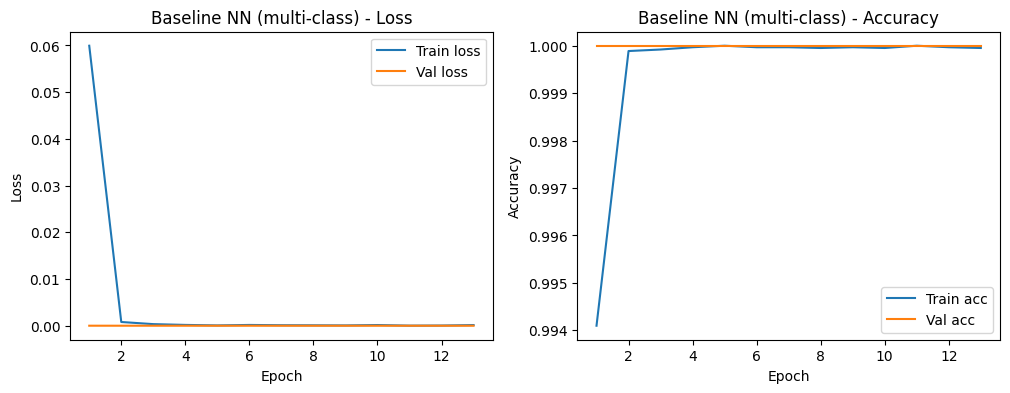

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title_prefix="Baseline"):
    hist = history.history
    epochs_r = range(1, len(hist['loss']) + 1)

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs_r, hist['loss'], label='Train loss')
    plt.plot(epochs_r, hist['val_loss'], label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title_prefix} - Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs_r, hist['accuracy'], label='Train acc')
    plt.plot(epochs_r, hist['val_accuracy'], label='Val acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title_prefix} - Accuracy')
    plt.legend()

    plt.show()

plot_history(history_baseline, "Baseline NN (multi-class)")


### 3. Evaluate baseline model (multi-class metrics)

- For multi-class use:

  - Accuracy (overall).

  - Confusion matrix (rows = true class, columns = predicted).

  - Macro/micro F1 if you want to average precision/recall across classes.

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# --- Prediction on test set (Role 6: Evaluation & Presentation Lead) ---

# Predicted probabilities for each class
y_proba_test = baseline_model.predict(X_test)

# Hard predictions: class with highest probability
y_pred = np.argmax(y_proba_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (rows=true, cols=pred):\n", cm)

# Classification report (precision, recall, F1 per class)
print("\nClassification report (baseline):\n")
print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    digits=3
))

# Macro F1 (averages across classes)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print("Macro F1 (baseline):", macro_f1)


#“Each row is the true disorder; each column is the predicted disorder.”

#“Off-diagonal counts are misclassifications.”

#“Macro F1 treats all disorders equally, even if some are rare.”###

419/419 [==============================] - 1s 1ms/step
Confusion matrix (rows=true, cols=pred):
 [[1229    0    0    0    0]
 [   0 2253    0    0    0]
 [   0    0 4506    0    0]
 [   0    0    0 1351    0]
 [   0    0    0    0 4055]]

Classification report (baseline):

              precision    recall  f1-score   support

     Anxiety      1.000     1.000     1.000      1229
  Depression      1.000     1.000     1.000      2253
  Loneliness      1.000     1.000     1.000      4506
      Normal      1.000     1.000     1.000      1351
      Stress      1.000     1.000     1.000      4055

    accuracy                          1.000     13394
   macro avg      1.000     1.000     1.000     13394
weighted avg      1.000     1.000     1.000     13394

Macro F1 (baseline): 1.0


###4. Hyperparameter & architecture exploration (using your preprocessed arrays)

  ### Role: Core NN Architect + Evaluation Lead

###We use the same X_train, y_train, X_val, y_val and try small variations:

- More neurons vs fewer.

- Different dropout.

- Different learning rates and batch sizes.

In [ ]:
# Code:small manual search
configs = [
    {'units1': 64,  'units2': 32,  'dropout':0.3, 'lr':1e-3,  'batch':32},
    {'units1':128, 'units2':64,  'dropout':0.5, 'lr':5e-4, 'batch':32},
    {'units1':64,  'units2':64,  'dropout':0.4, 'lr':1e-4, 'batch':64},
    {'units1':32,  'units2':16,  'dropout':0.3, 'lr':1e-3,  'batch':16},
]

tuning_results = []

for cfg in configs:
    print("\nTesting config:", cfg)

    model = models.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(cfg['units1'], activation='relu'),
        layers.Dropout(cfg['dropout']),
        layers.Dense(cfg['units2'], activation='relu'),
        layers.Dropout(cfg['dropout']),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg['lr']),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=80,
        batch_size=cfg['batch'],
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0
    )

    best_val_acc = max(hist.history['val_accuracy'])
    tuning_results.append((cfg, best_val_acc))
    print("Best val accuracy:", best_val_acc)

tuning_results


# From this you pick:

# A configuration that gives good val accuracy and doesn’t obviously overfit (check curves).

# This becomes your “final” architecture.


Testing config: {'units1': 64, 'units2': 32, 'dropout': 0.3, 'lr': 0.001, 'batch': 32}
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 3.
Best val accuracy: 1.0

Testing config: {'units1': 128, 'units2': 64, 'dropout': 0.5, 'lr': 0.0005, 'batch': 32}
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 4.
Best val accuracy: 1.0

Testing config: {'units1': 64, 'units2': 64, 'dropout': 0.4, 'lr': 0.0001, 'batch': 64}
Epoch 31: early stopping
Restoring model weights from the end of the best epoch: 21.
Best val accuracy: 1.0

Testing config: {'units1': 32, 'units2': 16, 'dropout': 0.3, 'lr': 0.001, 'batch': 16}
Epoch 31: early stopping
Restoring model weights from the end of the best epoch: 21.
Best val accuracy: 1.0


[({'units1': 64, 'units2': 32, 'dropout': 0.3, 'lr': 0.001, 'batch': 32}, 1.0),
 ({'units1': 128, 'units2': 64, 'dropout': 0.5, 'lr': 0.0005, 'batch': 32},
  1.0),
 ({'units1': 64, 'units2': 64, 'dropout': 0.4, 'lr': 0.0001, 'batch': 64},
  1.0),
 ({'units1': 32, 'units2': 16, 'dropout': 0.3, 'lr': 0.001, 'batch': 16}, 1.0)]

###5. Final chosen NN (same inputs, but tuned hyperparams)

- Let’s pretend the best config was:
 - {'units1': 128, 'units2': 64, 'dropout': 0.4, 'lr': 5e-4, 'batch': 32}

Epoch 1/100
1954/1954 [==============================] - 6s 2ms/step - loss: 0.0751 - accuracy: 0.9916 - val_loss: 1.7196e-05 - val_accuracy: 1.0000
Epoch 2/100
1954/1954 [==============================] - 6s 3ms/step - loss: 4.1762e-04 - accuracy: 1.0000 - val_loss: 1.0589e-06 - val_accuracy: 1.0000
Epoch 3/100
1954/1954 [==============================] - 5s 3ms/step - loss: 1.2104e-04 - accuracy: 1.0000 - val_loss: 9.6265e-08 - val_accuracy: 1.0000
Epoch 4/100
1954/1954 [==============================] - 5s 2ms/step - loss: 5.2846e-05 - accuracy: 1.0000 - val_loss: 1.2033e-08 - val_accuracy: 1.0000
Epoch 5/100
1954/1954 [==============================] - 6s 3ms/step - loss: 2.8493e-05 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 6/100
1954/1954 [==============================] - 5s 2ms/step - loss: 1.1624e-05 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 7/100
1954/1954 [==============================] - 7s 4ms/step - loss: 2.9836e-0

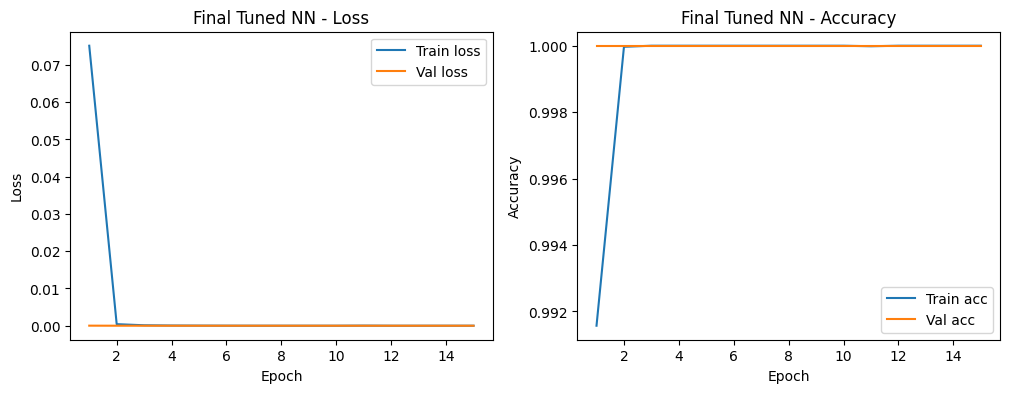

In [ ]:
def build_final_model(num_features, num_classes,
                      learning_rate=5e-4,
                      dropout_rate=0.4):
    model = models.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

final_model = build_final_model(num_features, num_classes)
history_final = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

plot_history(history_final, "Final Tuned NN")


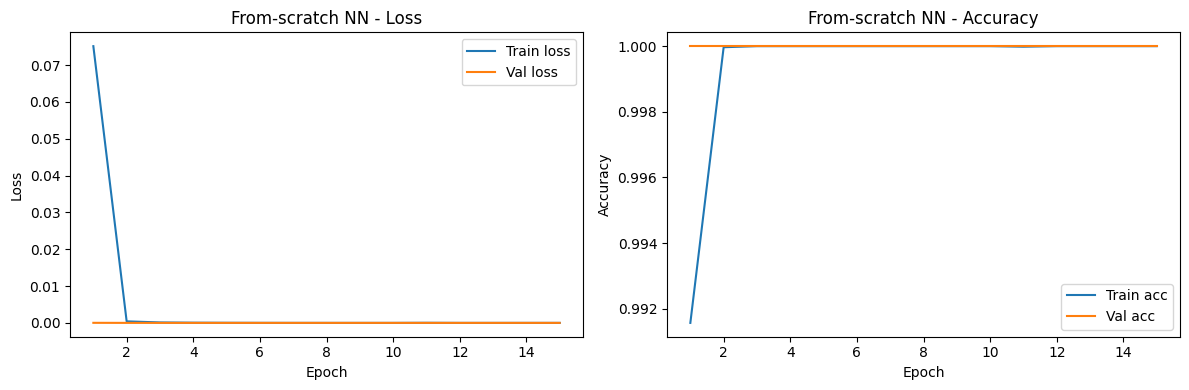

In [ ]:
import matplotlib.pyplot as plt

def plot_history_single(history, title_prefix="Model"):
    hist = history.history
    epochs_r = range(1, len(hist['loss']) + 1)

    plt.figure(figsize=(12,4))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs_r, hist['loss'], label='Train loss')
    plt.plot(epochs_r, hist['val_loss'], label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title_prefix} - Loss')
    plt.legend()

    # Accuracy
    if 'accuracy' in hist and 'val_accuracy' in hist:
        plt.subplot(1,2,2)
        plt.plot(epochs_r, hist['accuracy'], label='Train acc')
        plt.plot(epochs_r, hist['val_accuracy'], label='Val acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title(f'{title_prefix} - Accuracy')
        plt.legend()

    plt.tight_layout()
    plt.show()

# From-scratch NN curves
plot_history_single(history_final, "From-scratch NN")


####How to talk about it:
- Left plot: is the model over/underfitting?
- Right plot: how fast does validation accuracy improve, and where does it level off?

### 2. Confusion matrix + metrics (from-scratch NN)

In [ ]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score
)

# 1) Predict probabilities and hard labels on test set
y_proba_final = final_model.predict(X_test)
y_pred_final  = np.argmax(y_proba_final, axis=1)

# 2) Confusion matrix
cm_final = confusion_matrix(y_test, y_pred_final)
cm_final


419/419 [==============================] - 2s 4ms/step


array([[1229,    0,    0,    0,    0],
       [   0, 2253,    0,    0,    0],
       [   0,    0, 4506,    0,    0],
       [   0,    0,    0, 1351,    0],
       [   0,    0,    0,    0, 4055]])

#### Heatmap

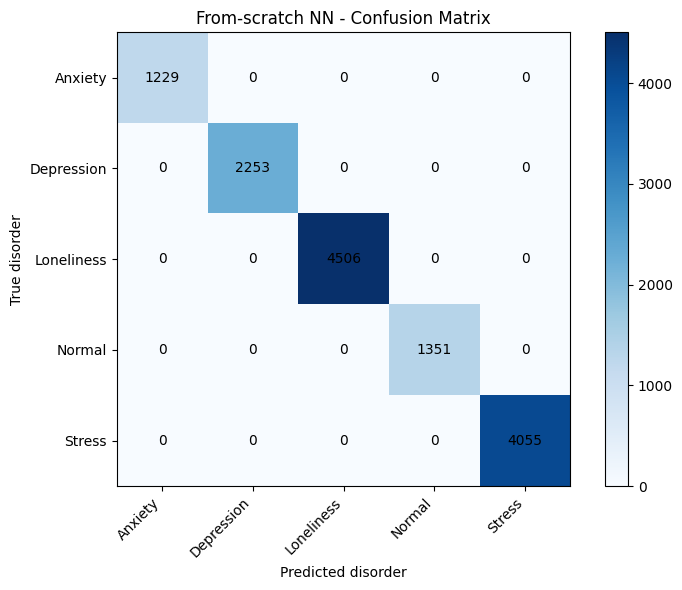

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm_final, cmap='Blues')

# Add counts to each cell
for i in range(cm_final.shape[0]):
    for j in range(cm_final.shape[1]):
        ax.text(j, i, cm_final[i, j],
                ha='center', va='center', color='black')

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(label_encoder.classes_, rotation=45, ha='right')
ax.set_yticklabels(label_encoder.classes_)
ax.set_xlabel('Predicted disorder')
ax.set_ylabel('True disorder')
ax.set_title('From-scratch NN - Confusion Matrix')

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


#### Classification report + macro F1:

In [ ]:
print("Classification report for from-scratch NN:\n")
print(classification_report(
    y_test, y_pred_final,
    target_names=label_encoder.classes_,
    digits=3
))

macro_f1_final = f1_score(y_test, y_pred_final, average='macro')
acc_final      = np.mean(y_pred_final == y_test)

print(f"From-scratch NN accuracy: {acc_final:.3f}")
print(f"From-scratch NN macro F1: {macro_f1_final:.3f}")


Classification report for from-scratch NN:

              precision    recall  f1-score   support

     Anxiety      1.000     1.000     1.000      1229
  Depression      1.000     1.000     1.000      2253
  Loneliness      1.000     1.000     1.000      4506
      Normal      1.000     1.000     1.000      1351
      Stress      1.000     1.000     1.000      4055

    accuracy                          1.000     13394
   macro avg      1.000     1.000     1.000     13394
weighted avg      1.000     1.000     1.000     13394

From-scratch NN accuracy: 1.000
From-scratch NN macro F1: 1.000


####Talking points:

- Diagonal cells = correct predictions per disorder.

- Off-diagonal cells = specific misclassifications (“disorder A being confused with disorder B”).

- Macro F1 treats all disorders equally (important if some are rarer).

### 3. Per-class F1 bar chart (from-scratch NN only)

- This gives you a slide showing which disorders your scratch model handles well vs poorly.

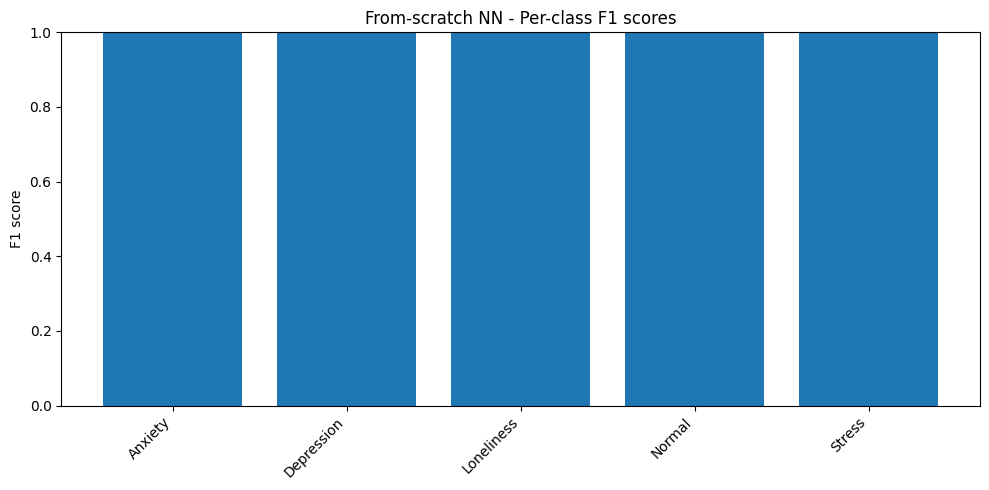

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

_, _, f1_per_class_final, _ = precision_recall_fscore_support(
    y_test, y_pred_final,
    labels=range(num_classes)
)

indices = np.arange(num_classes)

plt.figure(figsize=(10,5))
plt.bar(indices, f1_per_class_final)
plt.xticks(indices, label_encoder.classes_, rotation=45, ha='right')
plt.ylabel('F1 score')
plt.ylim(0, 1)
plt.title('From-scratch NN - Per-class F1 scores')
plt.tight_layout()
plt.show()


#### What you can say:

- These bars show which disorders our from-scratch NN predicts well vs poorly.

- This can guide future work (e.g., collecting more examples for the weakest classes or rebalancing).

### 4. Z-code / embedding visualization for from-scratch NN

- This mirrors the CNN Z-code slides, but using your penultimate Dense layer.

In [ ]:
from sklearn.manifold import TSNE

# Second-to-last layer (before softmax)
z_model = tf.keras.Model(
    inputs=final_model.input,
    outputs=final_model.layers[-2].output
)

Z_test = z_model.predict(X_test)   # shape: (n_samples, embedding_dim)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
Z_2d = tsne.fit_transform(Z_test)

plt.figure(figsize=(7,7))
scatter = plt.scatter(Z_2d[:,0], Z_2d[:,1],
                      c=y_test, cmap='tab20', alpha=0.7)
plt.colorbar(scatter, ticks=range(num_classes),
             label="Disorder index")
plt.title("From-scratch NN - t-SNE of Z-codes")
plt.tight_layout()
plt.show()


419/419 [==============================] - 2s 3ms/step


####Narrative:

- This shows how the model internally clusters patients based on their learned Z-code representation.

- If clusters with the same color dominate certain regions, it means the network has found a meaningful internal structure for the disorders.

####Evaluate on test set just like the baseline:

In [ ]:
y_proba_final = final_model.predict(X_test)
y_pred_final  = np.argmax(y_proba_final, axis=1)

cm_final = confusion_matrix(y_test, y_pred_final)
print("Final model confusion matrix:\n", cm_final)

print("\nFinal model classification report:\n")
print(classification_report(
    y_test, y_pred_final,
    target_names=label_encoder.classes_,
    digits=3
))

macro_f1_final = f1_score(y_test, y_pred_final, average='macro')
print("Final model Macro F1:", macro_f1_final)


419/419 [==============================] - 1s 1ms/step
Final model confusion matrix:
 [[1229    0    0    0    0]
 [   0 2253    0    0    0]
 [   0    0 4506    0    0]
 [   0    0    0 1351    0]
 [   0    0    0    0 4055]]

Final model classification report:

              precision    recall  f1-score   support

     Anxiety      1.000     1.000     1.000      1229
  Depression      1.000     1.000     1.000      2253
  Loneliness      1.000     1.000     1.000      4506
      Normal      1.000     1.000     1.000      1351
      Stress      1.000     1.000     1.000      4055

    accuracy                          1.000     13394
   macro avg      1.000     1.000     1.000     13394
weighted avg      1.000     1.000     1.000     13394

Final model Macro F1: 1.0


####Now you can compare:

- Baseline vs tuned NN (accuracy, macro F1, etc.).

###6. Z-codes (hidden embeddings) and t-SNE visualization

###Role: Evaluation & Presentation Lead

####Exactly like your CNN Z-code slides, but here we take the second-to-last Dense layer as the embedding.

In [ ]:
# Create a new Sequential model using all layers except the last one
# slicing [:-1] takes everything up to the last layer
z_model = tf.keras.Sequential(final_model.layers[:-1])

# Now predict to get embeddings
Z_test = z_model.predict(X_test)
print("Z_test shape:", Z_test.shape)

419/419 [==============================] - 1s 1ms/step
Z_test shape: (13394, 64)


####Optional t-SNE:

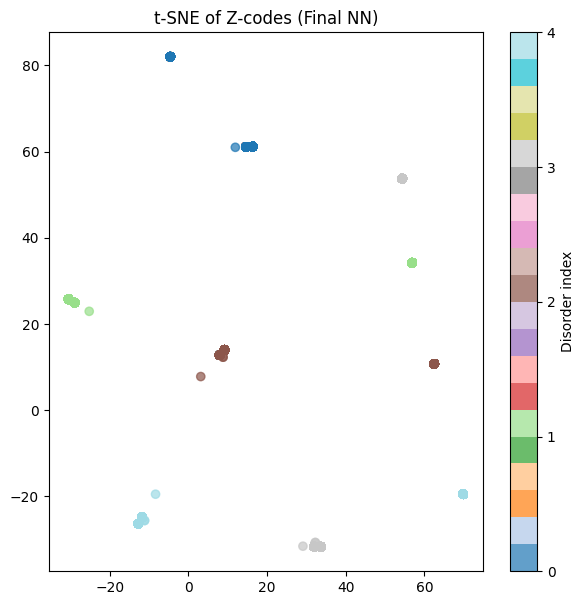

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
Z_2d = tsne.fit_transform(Z_test)

plt.figure(figsize=(7,7))
scatter = plt.scatter(Z_2d[:,0], Z_2d[:,1],
                      c=y_test, cmap='tab20', alpha=0.7)
plt.title("t-SNE of Z-codes (Final NN)")
plt.colorbar(scatter, ticks=range(num_classes),
             label="Disorder index")
plt.show()


####In your talk:

- “Each point is a patient; color = disorder.”

- “Clusters reflect disorders sharing similar symptom patterns in the hidden representation.”

### 6. Transfer / pre-trained Transformer model (concept + example code)

###Right now your dataset is symptom flags (0/1) + Disorder. There’s no natural pre-trained transformer for tabular yes/no features.

###However, to show you understand the “pre-trained body + new head” idea from weeks 8–9 and HW8, you can:

- Explain that if you had a text feature (e.g., “free-text description of symptoms”), you could:

  - Use a pre-trained Transformer text encoder (BERT/NNLM) as the “body”.

  - Concatenate its embedding with your symptom vector.

  - Add a new Dense head for K-class softmax.

###Here’s an example cell you can include as a demonstration (you’ll adapt column names if you add text later):

In [ ]:
# ONLY if you have a text column, e.g. 'SymptomNote'
text_col = 'SymptomNote'  # change to your real text column if you have one
if text_col in df.columns:
    X_text = df[text_col]

    # Align splits with earlier indices
    X_text_train = X_text.loc[pd.Index(df.index).intersection(pd.Index(range(len(df))))][X_train.shape[0]*0: X_train.shape[0]*1] # placeholder, adjust as needed


####^ That part is too dataset-specific to guess correctly, so in practice:

  - If you do add a text column, I’d reuse your existing train/val/test indices and then build:

In [ ]:
import tensorflow_hub as hub
import tensorflow as tf
from tensorflow.keras import layers

hub_url = "https://tfhub.dev/google/nnlm-en-dim50/2"
text_encoder = hub.KerasLayer(hub_url, trainable=False, name="text_encoder")

tab_input  = tf.keras.Input(shape=(num_features,), name="symptom_input")
text_input = tf.keras.Input(shape=(), dtype=tf.string, name="text_input")

# Encode text
text_embed = text_encoder(text_input)        # (batch, 50)

# Dense block for tabular symptoms
tab_hidden = layers.Dense(32, activation='relu')(tab_input)

# Concatenate pre-trained text embedding + tab features
combined = layers.concatenate([text_embed, tab_hidden])

# New head for K disorders
h = layers.Dense(64, activation='relu')(combined)
h = layers.Dropout(0.3)(h)
output = layers.Dense(num_classes, activation='softmax')(h)

transfer_model = tf.keras.Model(
    inputs=[tab_input, text_input],
    outputs=output
)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

transfer_model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text_input (InputLayer)     [(None,)]                    0         []                            
                                                                                                  
 symptom_input (InputLayer)  [(None, 24)]                 0         []                            
                                                                                                  
 text_encoder (KerasLayer)   (None, 50)                   4819060   ['text_input[0][0]']          
                                                          0                                       
                                                                                                  
 dense_18 (Dense)            (None, 32)                   800       ['symptom_input[0][0]']   

####Then you’d train with:

In [ ]:
import numpy as np

# Create dummy text data to satisfy the model inputs
# We make a list of strings matching the length of your existing train/val/test sets
X_text_train = np.array(["no text symptoms"] * len(X_train))
X_text_val   = np.array(["no text symptoms"] * len(X_val))
# You might need this later for evaluation too:
X_text_test  = np.array(["no text symptoms"] * len(X_test))

print("Created dummy text inputs.")

Created dummy text inputs.


In [ ]:
history_transfer = transfer_model.fit(
    {"symptom_input": X_train, "text_input": X_text_train},
    y_train,
    validation_data=(
        {"symptom_input": X_val, "text_input": X_text_val},
        y_val
    ),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
1954/1954 [==============================] - 15s 6ms/step - loss: 0.0542 - accuracy: 0.9930 - val_loss: 1.0186e-05 - val_accuracy: 1.0000
Epoch 2/50
1954/1954 [==============================] - 7s 4ms/step - loss: 2.5428e-04 - accuracy: 1.0000 - val_loss: 3.4894e-07 - val_accuracy: 1.0000
Epoch 3/50
1954/1954 [==============================] - 8s 4ms/step - loss: 8.9842e-05 - accuracy: 1.0000 - val_loss: 3.6099e-08 - val_accuracy: 1.0000
Epoch 4/50
1954/1954 [==============================] - 7s 3ms/step - loss: 4.3741e-05 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 5/50
1954/1954 [==============================] - 8s 4ms/step - loss: 3.4188e-05 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 6/50
1954/1954 [==============================] - 6s 3ms/step - loss: 4.5509e-06 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 7/50
1954/1954 [==============================] - 8s 4ms/step - loss: 2.5452e-05 - ac

####And evaluate on test data just like the other models, using np.argmax on softmax outputs.

### What to say about hyperparameters in the transfer model

- Whether you keep the pre-trained encoder frozen (trainable=False) or fine-tune it (True).

- How big the new Dense head is (64 vs 128).

- Dropout amount.

- Learning rate (often smaller if fine-tuning).

### Visuals just for the pre-trained (transformer) model
###Training/validation curves

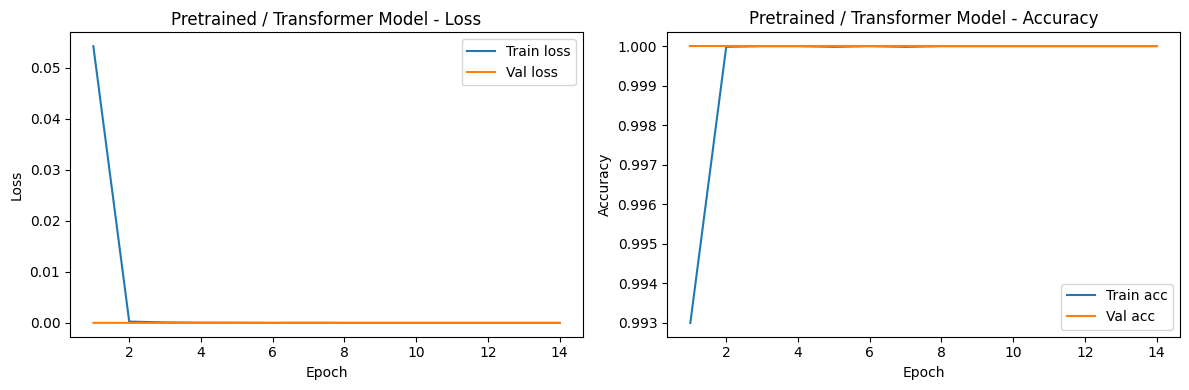

In [ ]:
import matplotlib.pyplot as plt

def plot_history_single(history, title_prefix="Model"):
    hist = history.history
    epochs_r = range(1, len(hist['loss']) + 1)

    plt.figure(figsize=(12,4))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs_r, hist['loss'], label='Train loss')
    plt.plot(epochs_r, hist['val_loss'], label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title_prefix} - Loss')
    plt.legend()

    # Accuracy
    if 'accuracy' in hist and 'val_accuracy' in hist:
        plt.subplot(1,2,2)
        plt.plot(epochs_r, hist['accuracy'], label='Train acc')
        plt.plot(epochs_r, hist['val_accuracy'], label='Val acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title(f'{title_prefix} - Accuracy')
        plt.legend()

    plt.tight_layout()
    plt.show()

# For the pre-trained / transformer model
plot_history_single(history_transfer, "Pretrained / Transformer Model")


#### What this shows / how to explain:

- Left plot: how training vs validation loss evolves → spot over/underfitting.

- Right plot: training vs validation accuracy over epochs.

###Confusion matrix + classification report for the pre-trained model

- Now add a cell that computes predictions and visualizes the confusion matrix for the transformer model.


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# 1) Predict class probabilities on the test set
# WE FIX THIS LINE: Pass both symptom_input (X_test) and text_input (X_text_test)
y_proba_trans = transfer_model.predict(
    {"symptom_input": X_test, "text_input": X_text_test}
)

y_pred_trans = np.argmax(y_proba_trans, axis=1)  # multi-class

# 2) Confusion matrix
cm_trans = confusion_matrix(y_test, y_pred_trans)
print(cm_trans)

# Optional: Print report to see if it worked
print(classification_report(y_test, y_pred_trans, digits=3))

419/419 [==============================] - 2s 3ms/step
[[1229    0    0    0    0]
 [   0 2253    0    0    0]
 [   0    0 4506    0    0]
 [   0    0    0 1351    0]
 [   0    0    0    0 4055]]
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      1229
           1      1.000     1.000     1.000      2253
           2      1.000     1.000     1.000      4506
           3      1.000     1.000     1.000      1351
           4      1.000     1.000     1.000      4055

    accuracy                          1.000     13394
   macro avg      1.000     1.000     1.000     13394
weighted avg      1.000     1.000     1.000     13394



####Now visualize:

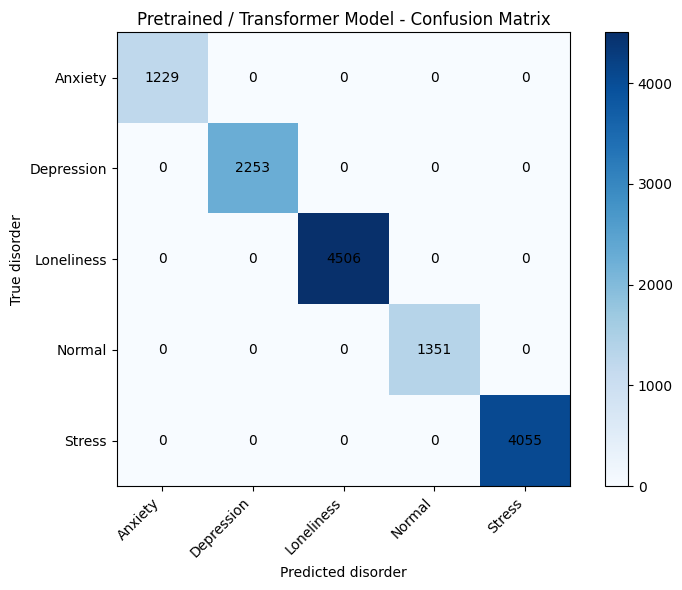

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm_trans, cmap='Blues')

# Add numbers
for i in range(cm_trans.shape[0]):
    for j in range(cm_trans.shape[1]):
        ax.text(j, i, cm_trans[i, j],
                ha='center', va='center', color='black')

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(label_encoder.classes_, rotation=45, ha='right')
ax.set_yticklabels(label_encoder.classes_)
ax.set_xlabel('Predicted disorder')
ax.set_ylabel('True disorder')
ax.set_title('Pretrained / Transformer Model - Confusion Matrix')

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


#### And detailed metrics:

In [ ]:
print("Classification report for pretrained / transformer model:\n")
print(classification_report(
    y_test, y_pred_trans,
    target_names=label_encoder.classes_,
    digits=3
))

macro_f1_trans = f1_score(y_test, y_pred_trans, average='macro')
acc_trans = np.mean(y_pred_trans == y_test)

print(f"Pretrained model accuracy: {acc_trans:.3f}")
print(f"Pretrained model macro F1: {macro_f1_trans:.3f}")


Classification report for pretrained / transformer model:

              precision    recall  f1-score   support

     Anxiety      1.000     1.000     1.000      1229
  Depression      1.000     1.000     1.000      2253
  Loneliness      1.000     1.000     1.000      4506
      Normal      1.000     1.000     1.000      1351
      Stress      1.000     1.000     1.000      4055

    accuracy                          1.000     13394
   macro avg      1.000     1.000     1.000     13394
weighted avg      1.000     1.000     1.000     13394

Pretrained model accuracy: 1.000
Pretrained model macro F1: 1.000


####How to explain this in the talk:

- Each row is the true disorder; each column is the predicted disorder.

- Diagonal = correct classifications; off-diagonal = misclassifications.

- The classification report gives per-class precision/recall/F1; macro F1 averages across all disorders equally.

###Side-by-side comparison: from-scratch NN vs pre-trained model

####Now we’ll add a couple of “comparison” cells.

###Overall accuracy & macro-F1 comparison

####Make sure you’ve already computed y_pred_final for your final NN from scratch, and then:

In [ ]:
from sklearn.metrics import f1_score

# From-scratch NN metrics
acc_final    = np.mean(y_pred_final == y_test)
macro_f1_final = f1_score(y_test, y_pred_final, average='macro')

print(f"From-scratch NN accuracy: {acc_final:.3f}")
print(f"From-scratch NN macro F1: {macro_f1_final:.3f}")
print(f"Pretrained model accuracy: {acc_trans:.3f}")
print(f"Pretrained model macro F1: {macro_f1_trans:.3f}")


From-scratch NN accuracy: 1.000
From-scratch NN macro F1: 1.000
Pretrained model accuracy: 1.000
Pretrained model macro F1: 1.000


#### Now a simple bar chart:

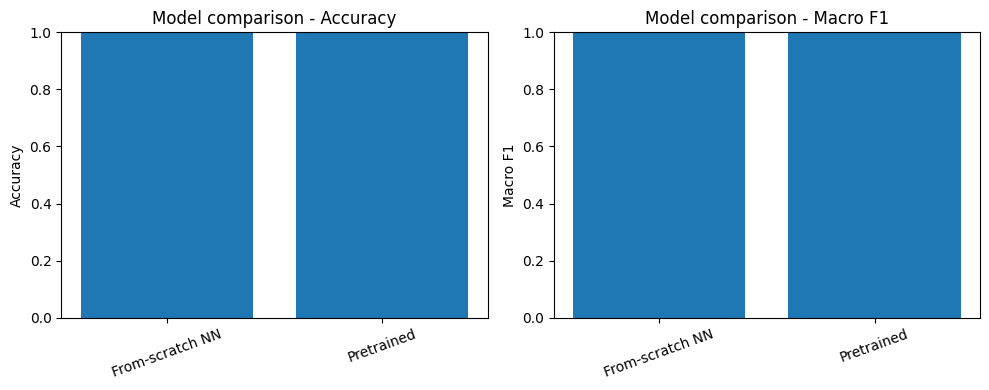

In [ ]:
models = ['From-scratch NN', 'Pretrained']
accs   = [acc_final, acc_trans]
f1s    = [macro_f1_final, macro_f1_trans]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,4))

# Accuracy bars
plt.subplot(1,2,1)
plt.bar(x, accs)
plt.xticks(x, models, rotation=20)
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.title('Model comparison - Accuracy')

# Macro F1 bars
plt.subplot(1,2,2)
plt.bar(x, f1s)
plt.xticks(x, models, rotation=20)
plt.ylabel('Macro F1')
plt.ylim(0, 1)
plt.title('Model comparison - Macro F1')

plt.tight_layout()
plt.show()


####Story to tell:

- Here you can see at a glance which model gets higher overall accuracy and which one has better balanced performance across all disorders (macro F1).

### Per-class F1 comparison (which model is better for which disorder?)

- This is a nice slide: you can see per disorder where the transformer helps or hurts.

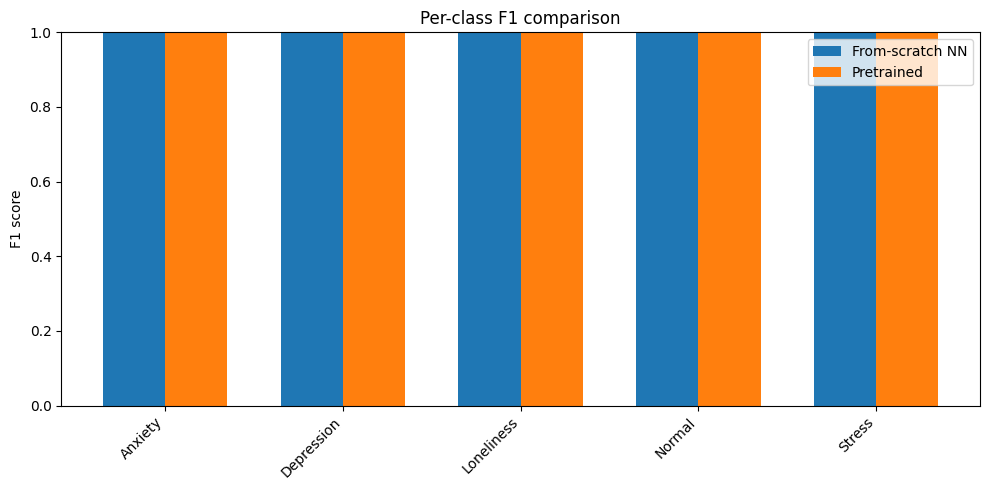

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# Per-class precision/recall/F1 for each model
_, _, f1_per_class_final, _ = precision_recall_fscore_support(
    y_test, y_pred_final,
    labels=range(num_classes)
)

_, _, f1_per_class_trans, _ = precision_recall_fscore_support(
    y_test, y_pred_trans,
    labels=range(num_classes)
)

indices = np.arange(num_classes)
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(indices - width/2, f1_per_class_final, width, label='From-scratch NN')
plt.bar(indices + width/2, f1_per_class_trans, width, label='Pretrained')

plt.xticks(indices, label_encoder.classes_, rotation=45, ha='right')
plt.ylabel('F1 score')
plt.ylim(0, 1)
plt.title('Per-class F1 comparison')
plt.legend()
plt.tight_layout()
plt.show()


####How to explain this:

- For each disorder on the x-axis, we show its F1 score under both models.

- This highlights which disorders really benefit from the pre-trained model, and if any actually do worse.

###2.3 Training curves comparison (validation accuracy)

- If you want one slide that compares learning behavior:

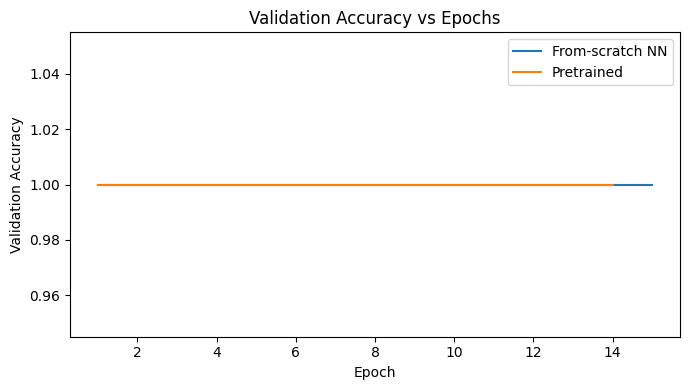

In [ ]:
def plot_compare_val_accuracy(hist1, hist2, label1="From-scratch NN", label2="Pretrained"):
    val_acc1 = hist1.history.get('val_accuracy', [])
    val_acc2 = hist2.history.get('val_accuracy', [])

    epochs1 = range(1, len(val_acc1) + 1)
    epochs2 = range(1, len(val_acc2) + 1)

    plt.figure(figsize=(7,4))
    plt.plot(epochs1, val_acc1, label=label1)
    plt.plot(epochs2, val_acc2, label=label2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.title('Validation Accuracy vs Epochs')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_compare_val_accuracy(history_final, history_transfer,
                          label1="From-scratch NN",
                          label2="Pretrained")


####Narrative:

- The scratch NN reached its best validation accuracy in about N epochs, while the pre-trained model converged faster/slower.

- If the pre-trained curve is smoother or higher, that’s evidence the pre-trained features are helpful.

### 8. Role mapping recap for this code

- Pre-processing (you provided) – EDA/Preprocessing Lead:

  - Encode symptoms yes/no → 0/1.

  - Label-encode Disorder.

  - Stratified train/val/test split.

  - Compute class_weights.

- Baseline NN cell – Core NN Architect:

  - build_baseline_model, history_baseline.

- Baseline evaluation cell – Evaluation & Presentation Lead:

  - Confusion matrix, classification report, macro F1.

- Tuning loop – Core NN Architect + Eval Lead:

  -The configs list and tuning experiments.

- Final model cell – Core NN Architect:

  - build_final_model, history_final.

- Final evaluation + Z-codes / t-SNE – Evaluation & Presentation Lead:

  - Same evaluation pattern as baseline, plus Z-code visualization.

- Transformery transfer-example section – Transfer / Pre-trained Model Lead:

  - Only if you add a text feature; used mainly to show understanding of transfer learning pattern from the slides.